# KABUL-1: AAPL, eski çizgi + takip eden stop

> **Durum:** ✅ şimdilik kabul (kullanıcı kararı, 2026-09-11)
> **Kayıt:** `hypotheses/KABUL-1_AAPL_takip_eden_stop.md` · `hypotheses/REGISTRY.md`

**Sistem, tek cümle:** fiyat son 20 günün dibine yaklaşınca al; tepeye değince
satma, o andan sonraki en yüksek fiyattan bir kanal genişliği kadar düşünce sat;
fiyat dibin çok altına inerse zararına sat.

**Baseline:** test döneminin başında al, hiçbir şey yapmadan sonunda sat.

---

**Bu defter bir şablondur.** Başka bir sistem için sadece **0. Ayarlar**
hücresi değişir, geri kalan her şey aynen çalışır.

| adım | ne gösterir |
|---|---|
| 1 | Hangi veri kullanıldı, saklanan veri nerede |
| 2 | Çizgiler nasıl çiziliyor |
| 3 | Eğitim: her yıl hangi ayarlar seçildi, neden |
| 4 | Bir işlemin baştan sona hikâyesi |
| 5 | Test sonucu: 1 lira ne oldu |
| 6 | Test yıllarındaki tüm işlemler |
| 7 | Hangi koşullarda kâr ettirdi |
| 8 | Saatlik veriyle karşılaştırma |
| 8b | Dakikalık veriyle karşılaştırma |
| 8c | Baseline ile fark ne kadar hızlı açıldı |
| 9 | Sınırlar ve sonraki adımlar |

## 0. Ayarlar

In [1]:
# === Şablonun değişen tek yeri ===
SEMBOL        = 'AAPL'
FREKANS       = '1Day'                 # '1Day' | '1Hour' | '1Min'
PENCERE_GUN   = 20                     # çizgiler son kaç günden çizilir
SABIT         = {'cizgi': 'donchian',  # 'donchian': son N günün en yükseği/en düşüğü
                 'satis': 'takip'}     # 'takip': tepeye değince satma, takip eden stop
TEST_YILLARI  = range(2019, 2025)      # her yıl sadece önceki yıllarla eğitilir
MALIYET       = 0.0005                 # her alışta ve her satışta %0.05
KASA_BITIS    = '2026-09-04'           # saklanan verinin son günü (sadece grafikte işaret için)

# --- buradan sonrası ayarlardan türetilir ---
GUN_BAR     = {'1Hour': 7, '1Min': 390}.get(FREKANS, 1)   # günde bar: saatlikte 7, dakikalıkta 390 (09:30-16:00)
N           = PENCERE_GUN * GUN_BAR
BAR_PER_YIL = 252 * GUN_BAR
print(f'{SEMBOL} {FREKANS} | çizgi {PENCERE_GUN} gün = {N} bar | {SABIT} | '
      f'test {TEST_YILLARI.start}-{TEST_YILLARI.stop - 1}')

AAPL 1Day | çizgi 20 gün = 20 bar | {'cizgi': 'donchian', 'satis': 'takip'} | test 2019-2024


In [2]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd

from src.data.load import load_bars
from lab.session import regular_hours, regular_minutes
from lab.splits import split_research_vault, VAULT_BEGINS
from lab.backtest import Kurallar, calistir, egitim_test_detay, zincirle, al_tut
from lab import plots

pd.set_option('display.float_format', lambda v: f'{v:,.3f}')


def veri_yukle(sembol, frekans):
    # sadece araştırma dönemi; saklanan veri (kasa) burada ayrılır ve kullanılmaz
    df = load_bars(sembol, frekans)
    if frekans == '1Hour':
        df = regular_hours(df)            # sadece borsa saatleri
    elif frekans == '1Min':
        df = regular_minutes(df)          # sadece borsa saatleri, 09:30-15:59
    if df['timestamp'].max() < pd.Timestamp(VAULT_BEGINS, tz='UTC'):
        return df                         # saklanan dönem hiç indirilmedi (dakikalık veri)
    return split_research_vault(df, horizon_bars=1).research


def test_dilimi(veri, yil, n):
    # bir test yılının verisi + başındaki n ısınma barı (çizgiler hazır olsun diye)
    ts = veri['timestamp']
    bas = ts.searchsorted(pd.Timestamp(f'{yil}-01-01', tz='UTC'))
    son = ts.searchsorted(pd.Timestamp(f'{yil + 1}-01-01', tz='UTC'))
    return veri.iloc[bas - n:son]

## 1. Veri

Sadece **araştırma dönemi** kullanılır. 2024 Temmuz'dan sonrası saklanan
veridir (kasa): sistem kesinleşince bir kez açılacak. Grafikte yeri gri
alanla gösterilir, fiyatları çizilmez.

2135 bar | 2016-01-04 → 2024-06-27


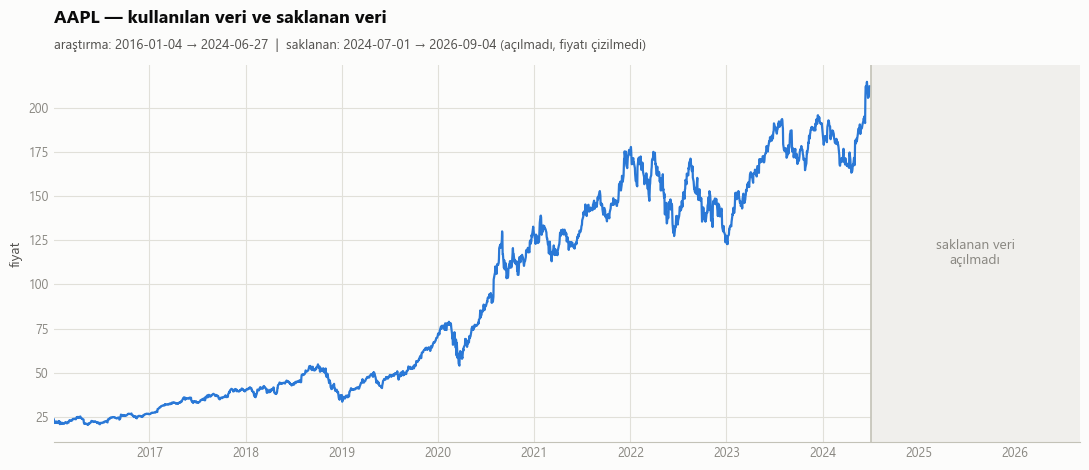

In [3]:
veri = veri_yukle(SEMBOL, FREKANS)
print(f"{len(veri)} bar | {veri['timestamp'].iloc[0].date()} → {veri['timestamp'].iloc[-1].date()}")
plots.price_split_chart(veri, VAULT_BEGINS, KASA_BITIS, sembol=SEMBOL);

## 2. Çizgiler nasıl çiziliyor

* **Tepe çizgisi:** son 20 günün en yüksek fiyatı. **Dip çizgisi:** en düşük fiyatı.
* O anki gün hesaba katılmaz, sadece öncekiler.
* Her gün pencere bir gün kayar: en eski gün çıkar, dünkü gün girer. Çizgi
  ancak yeni bir zirve/dip gelince ya da eski zirve/dip pencereden çıkınca
  değişir. Bu yüzden basamak basamak hareket eder.
* **Alış seviyesi** (noktalı mavi): dip + iki çizgi arasındaki mesafenin %10'u. Sadece elde hisse
  yokken çizilir; grafiğin çoğunda sistem hissede olduğu için görünmez.
* Gri dikey çubuklar her günün en düşüğü–en yükseği. Çizgiler bunlardan
  çizilir, kapanıştan değil. Bu yüzden kapanış çizgiye hiç değmeden de çizgi
  yükselebilir.
* **Fiyat çizgiyi aşabilir.** Bir gün 20 günün zirvesinin üstüne çıkarsa (▲)
  o gün tepe çizgisinin üstündedir; tepe çizgisi ertesi gün o yeni zirveye
  sıçrar. Dipte de aynısı (▼). Bu bir hata değil: çizgi o günü henüz
  bilmiyor, sadece önceki günlere bakıyor.

Gri alan, grafiğin son gününün çizgilerini belirleyen 20 günlük pencere.

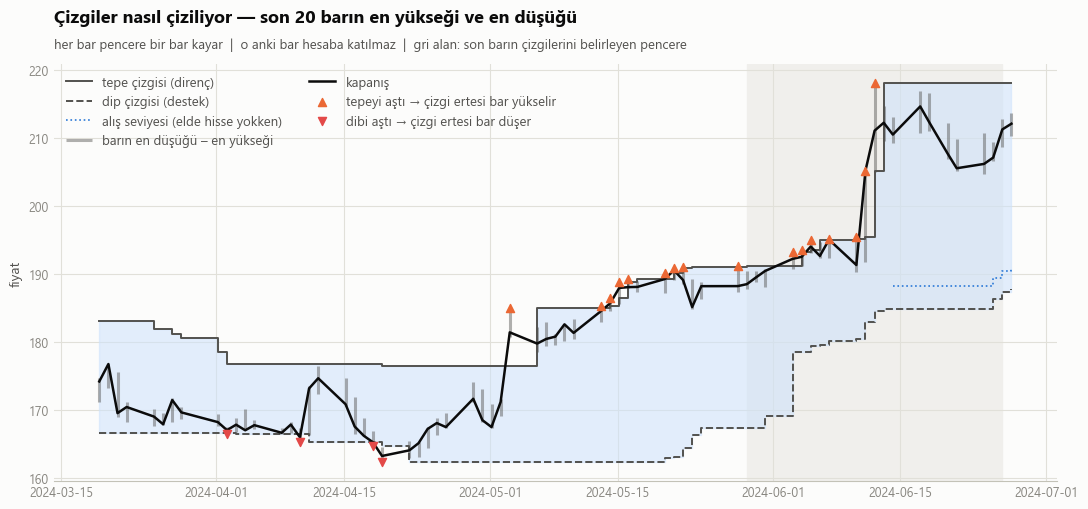

In [4]:
ornek = calistir(veri, Kurallar(n=N, maliyet=MALIYET, **SABIT))
son_gun = veri['timestamp'].iloc[-1]
plots.lines_chart(veri, ornek, son_gun - pd.Timedelta(days=100), son_gun);

## 3. Eğitim

Her test yılı için, **o yıldan önceki** tüm yıllarda 36 ayar denenir ve en çok
kazandıranı seçilir:

| ayar | denenen değerler | anlamı |
|---|---|---|
| alım payı | 0.05, 0.10, 0.20 | dipten, iki çizgi arası mesafenin ne kadarı yukarıda alınır |
| zararına satış payı | 0.25, 0.5, 1.0, 2.0 | alırkenki dipten mesafenin kaç katı aşağıda zararına satılır |
| takip mesafesi | 0.25, 0.5, 1.0 | tepeye değdikten sonra, en yüksekten mesafenin kaç katı düşünce satılır |

Test yılına eşik seçerken hiç bakılmaz.

In [5]:
tablo, yil_sonuclari, skorlar = egitim_test_detay(
    veri, n=N, test_yillari=TEST_YILLARI, maliyet=MALIYET, sabit=SABIT)

secimler = tablo.filter(regex='test_yili|secilen_').copy()
secimler.insert(1, 'eğitim dönemi', [f'2016-{y - 1}' for y in secimler['test_yili']])
secimler.set_index('test_yili')

,eğitim dönemi,secilen_alim,secilen_stop,secilen_takip
test_yili,,,,
2019,2016-2018,0.100,0.250,1.000
2020,2016-2019,0.100,2.000,1.000
2021,2016-2020,0.100,2.000,1.000
2022,2016-2021,0.100,2.000,1.000
2023,2016-2022,0.100,2.000,1.000
2024,2016-2023,0.100,2.000,1.000


Son eğitim döneminde (2016-2023) 36 ayarın her birinin sonucu. Kalın
çerçeve seçileni gösterir. Seçilen ayar tablonun **kenarındaysa**, denenen
aralığın dışında daha iyi bir değer olabilir demektir.

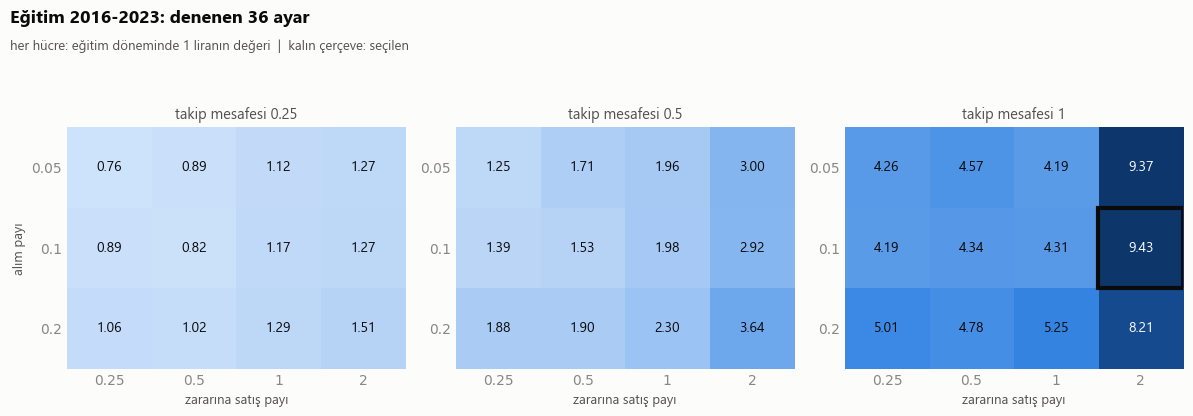

In [6]:
son_yil = max(TEST_YILLARI)
# secilen_alim → alim_payi, secilen_stop → stop_payi, secilen_takip → takip_payi
secilen = {k.replace('secilen_', '') + '_payi': v
           for k, v in tablo.iloc[-1].filter(like='secilen_').items()}
plots.grid_heatmap(skorlar[son_yil], secilen,
                   baslik=f'Eğitim 2016-{son_yil - 1}: denenen 36 ayar');

## 4. Bir işlemin anatomisi

Test yıllarından gerçek bir işlem: takip eden stopla kapanan en kazançlı işlem.

* **Mavi üçgen:** alış (fiyat alış seviyesine indi).
* **Kırmızı çizgi:** zararına satış seviyesi, alışta sabitlenir.
* **Turuncu halka:** fiyat tepe çizgisine değdi. Satılmadı, takip eden stop başladı.
* **Turuncu çizgi:** takip eden stop. Fiyat yükseldikçe yukarı taşınır, hiç inmez.
* **Elmas:** satış (fiyat takip eden stopa indi).

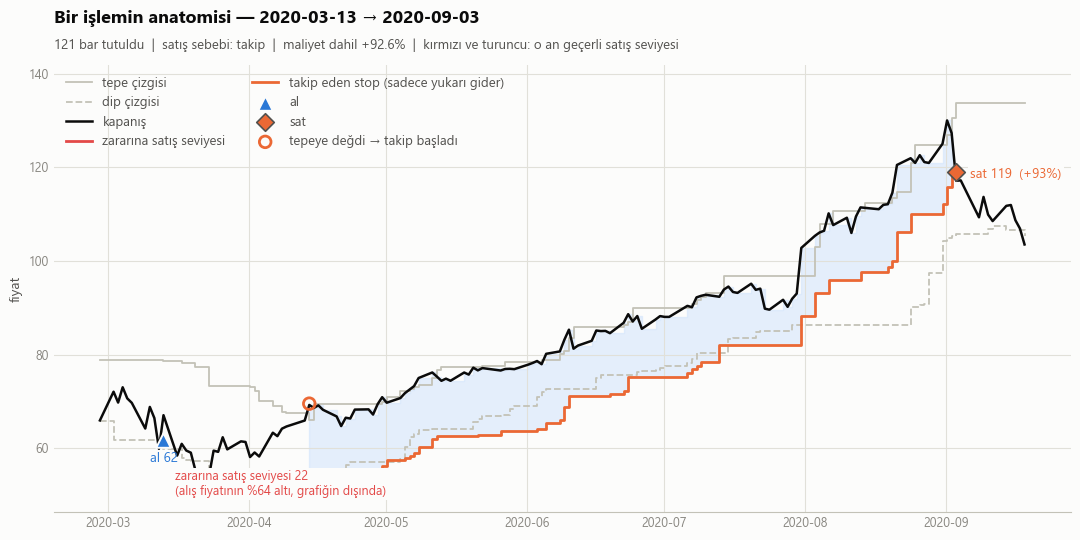

In [7]:
aday = []
for yil, s in yil_sonuclari.items():
    for i, r in s.islemler.iterrows():
        aday.append((r['sebep'] == 'takip', r['getiri_maliyetli'], yil, i))
_, _, ornek_yil, ornek_no = max(aday)     # önce takiple kapananlar, sonra en kazançlısı
plots.trade_anatomy_chart(test_dilimi(veri, ornek_yil, N), yil_sonuclari[ornek_yil], ornek_no);

## 5. Test sonucu (sadece test yılları)

Her test yılı kendi eğitimiyle çalıştırıldı; yıllar arka arkaya bağlanarak
1 liranın 2019 başından bugüne nasıl büyüdüğü çizilir.

**Baseline iki şekilde hesaplanabilir:**
* **kesintisiz:** test başında al, sonunda sat. Tek bir alış-satış maliyeti. Grafikteki eğri.
* **yıl yıl:** her yıl ayrı alınıp satılmış gibi (sistemin test yöntemiyle aynı).
  REGISTRY'deki 5.63 bu. Her yıl maliyet ödendiği için biraz daha düşük.

In [8]:
sistem = zincirle(yil_sonuclari, N)
baseline = al_tut(veri, f'{TEST_YILLARI.start}-01-01', maliyet=MALIYET)
tum_islemler = pd.concat([s.islemler.assign(test_yili=y) for y, s in yil_sonuclari.items()],
                         ignore_index=True)
test_bar = len(sistem)

pd.Series({
    'sistem — 1 lira →': sistem.iloc[-1],
    'baseline, kesintisiz — 1 lira →': baseline.iloc[-1],
    'baseline, yıl yıl — 1 lira →': tablo['basta_al_sonda_sat'].add(1).prod(),
    "baseline'ı geçtiği yıl": f"{int((tablo['testte'] > tablo['basta_al_sonda_sat']).sum())} / {len(tablo)}",
    'işlem sayısı': len(tum_islemler),
    'piyasada kalma': f"{tum_islemler['bar'].sum() / test_bar:.0%}",
    'en büyük erime (sistem)': f"{(sistem / sistem.cummax() - 1).min():.1%}",
    'en büyük erime (baseline)': f"{(baseline / baseline.cummax() - 1).min():.1%}",
}, name='test yılları').to_frame()

,test yılları
sistem — 1 lira →,5.804
"baseline, kesintisiz — 1 lira →",5.662
"baseline, yıl yıl — 1 lira →",5.634
baseline'ı geçtiği yıl,4 / 6
işlem sayısı,22
piyasada kalma,84%
en büyük erime (sistem),-27.6%
en büyük erime (baseline),-31.4%


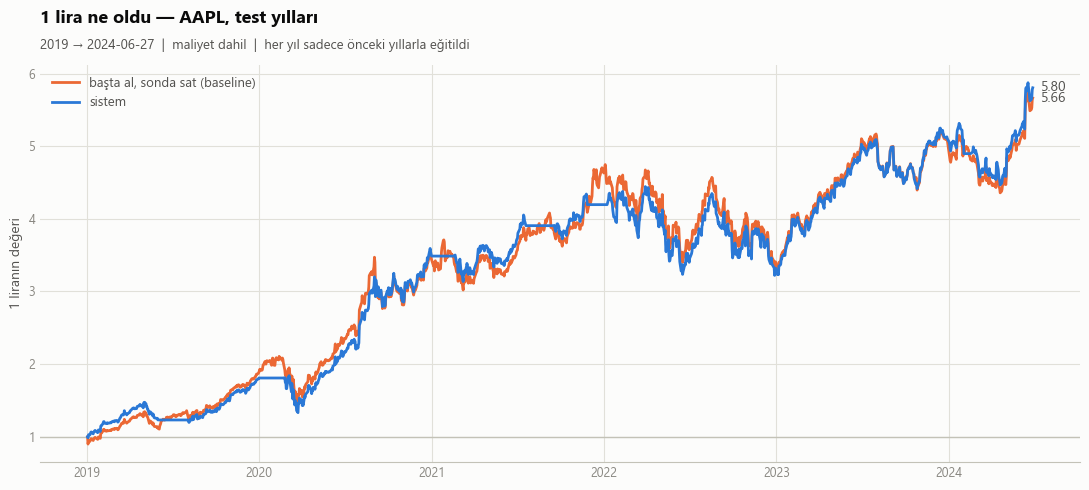

In [9]:
plots.compare_equity_chart(
    sistem, baseline,
    baslik=f'1 lira ne oldu — {SEMBOL}, test yılları',
    alt_baslik=f'{TEST_YILLARI.start} → {sistem.index[-1].date()}  |  maliyet dahil  |  '
               'her yıl sadece önceki yıllarla eğitildi');

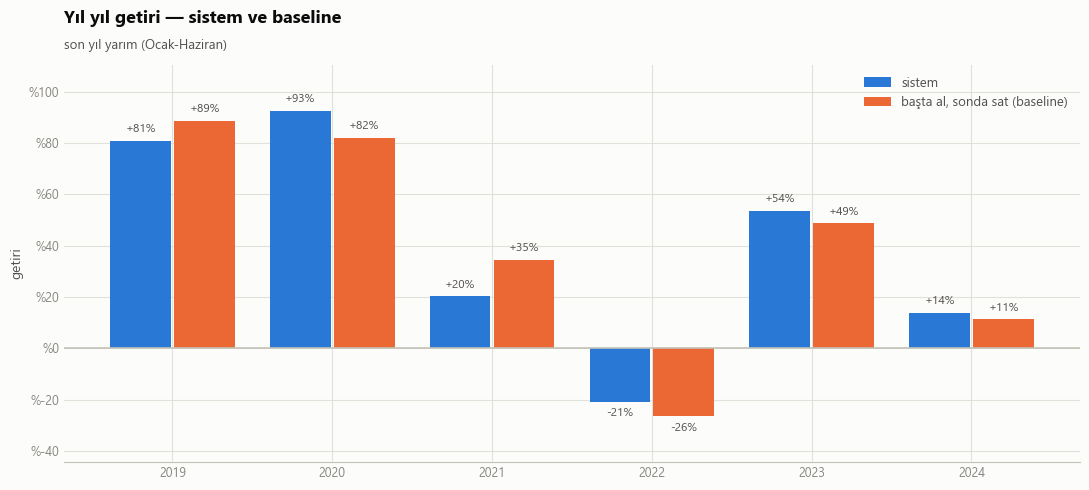

In [10]:
plots.yearly_bars_chart(
    tablo['test_yili'], tablo['testte'], tablo['basta_al_sonda_sat'],
    baslik='Yıl yıl getiri — sistem ve baseline',
    alt_baslik='son yıl yarım (Ocak-Haziran)');

## 6. İşlemler

Test yıllarındaki tüm alışlar ve satışlar. Dikey çizgiler yıl sınırları: her
yıl ayrı eğitildiği için yıl sonunda elde hisse varsa satılır (gri daire) ve
yeni yıl boş başlar. Gerçek bir sistemde bu satışlar olmaz.

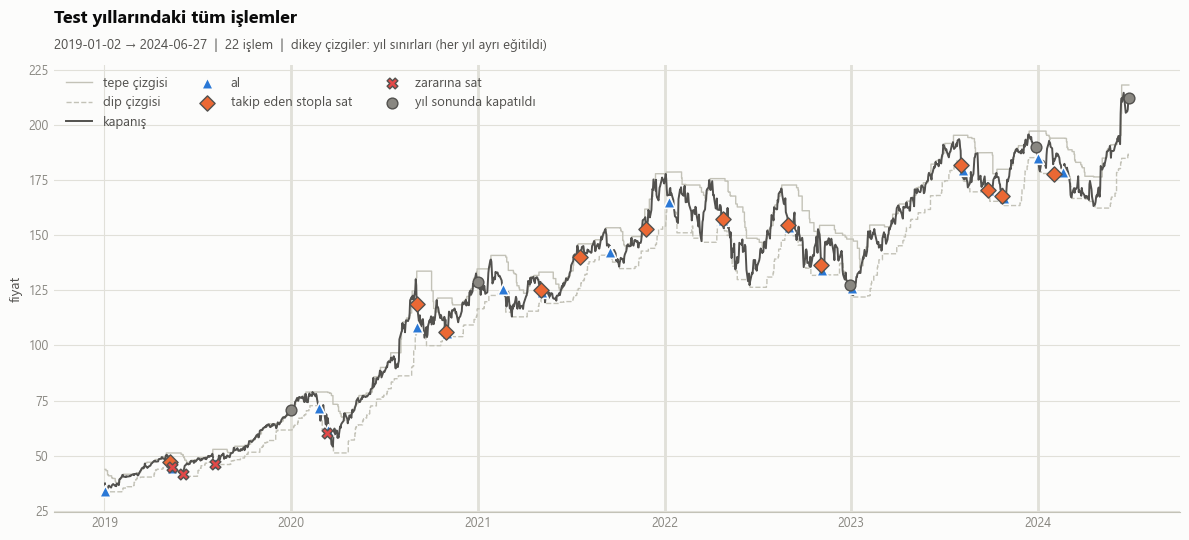

In [11]:
plots.test_trades_chart(veri, yil_sonuclari);

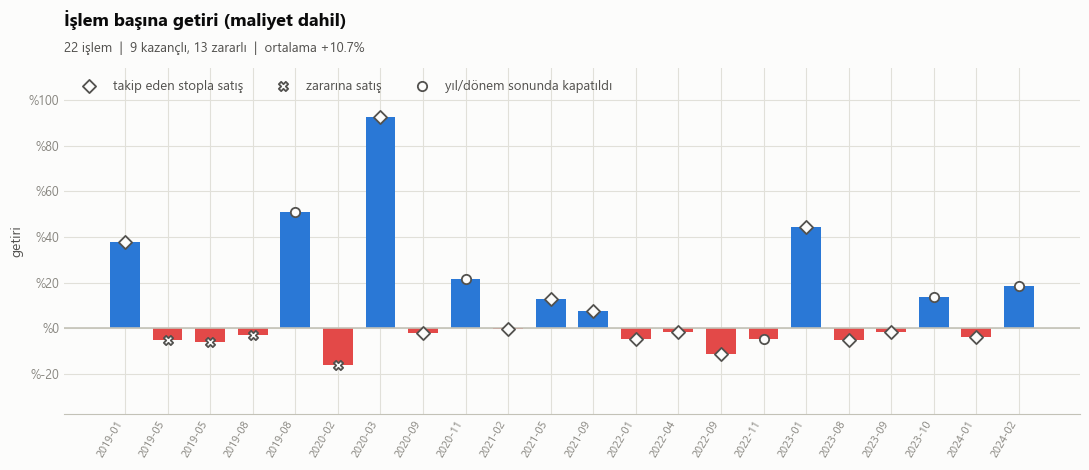

In [12]:
plots.trade_returns_chart(tum_islemler);

In [13]:
goster = tum_islemler.assign(
    alis_zamani=pd.to_datetime(tum_islemler['alis_zamani']).dt.date,
    satis_zamani=pd.to_datetime(tum_islemler['satis_zamani']).dt.date,
    gun=(tum_islemler['bar'] / GUN_BAR).round().astype(int),
)[['test_yili', 'alis_zamani', 'alis', 'satis_zamani', 'satis', 'gun', 'sebep', 'getiri_maliyetli']]
goster.rename(columns={'gun': 'tutma (işlem günü)', 'getiri_maliyetli': 'getiri'})

,test_yili,alis_zamani,alis,satis_zamani,satis,tutma (işlem günü),sebep,getiri
0,2019,2019-01-03,34.130,2019-05-09,47.140,87,takip,0.380
1,2019,2019-05-10,47.165,2019-05-13,44.860,1,stop,-0.050
2,2019,2019-05-14,44.456,2019-06-03,41.810,13,stop,-0.060
3,2019,2019-08-05,47.320,2019-08-05,46.047,0,stop,-0.028
4,2019,2019-08-06,46.718,2019-12-31,70.660,102,donem_sonu,0.511
5,2020,2020-02-24,71.700,2020-03-12,60.320,13,stop,-0.160
6,2020,2020-03-13,61.706,2020-09-03,118.980,121,takip,0.926
7,2020,2020-09-04,108.538,2020-10-30,106.280,39,takip,-0.022
8,2020,2020-11-02,105.740,2020-12-31,128.820,41,donem_sonu,0.217
9,2021,2021-02-18,125.620,2021-05-04,125.070,52,takip,-0.005


## 7. Hangi koşullarda kâr ettirdi

Zirveden kayıp: her an, paranın o ana kadarki en yüksek değerine göre ne
kadar eridiği. 0 = zirvede. Düşüş dönemlerinde sistemin çizgisi baseline'ın
üstünde kalıyorsa, sistem düşüşün bir kısmından kaçmış demektir.

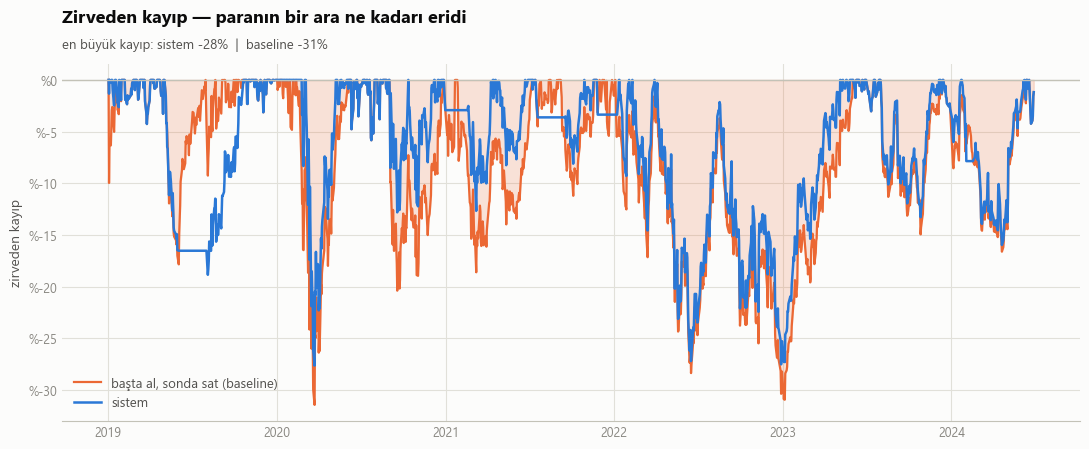

In [14]:
plots.drawdown_chart(sistem, baseline);

In [15]:
yillik = tablo[['test_yili', 'testte', 'basta_al_sonda_sat']].rename(
    columns={'testte': 'sistem', 'basta_al_sonda_sat': 'baseline'})
yillik['fark'] = yillik['sistem'] - yillik['baseline']
yillik['işlem'] = [len(yil_sonuclari[y].islemler) for y in yillik['test_yili']]
yillik['satış sebepleri'] = [yil_sonuclari[y].islemler['sebep'].value_counts().to_dict()
                             for y in yillik['test_yili']]
yillik.set_index('test_yili')

,sistem,baseline,fark,işlem,satış sebepleri
test_yili,,,,,
2019,0.809,0.886,-0.077,5,"{'stop': 3, 'takip': 1, 'donem_sonu': 1}"
2020,0.927,0.821,0.106,4,"{'takip': 2, 'stop': 1, 'donem_sonu': 1}"
2021,0.203,0.345,-0.142,3,{'takip': 3}
2022,-0.208,-0.265,0.056,4,"{'takip': 3, 'donem_sonu': 1}"
2023,0.536,0.489,0.047,4,"{'takip': 3, 'donem_sonu': 1}"
2024,0.138,0.114,0.024,2,"{'takip': 1, 'donem_sonu': 1}"


**Yorum (KABUL-1, 6 test yılından; kanıt değil, beklenti):**

* **Baseline'ı geçtiği durumlar:** sert düşüş ve toparlanma (2020), düşüş yılı
  (2022). Takip eden stop düşüşün bir kısmında sattırıyor, sistem dibe
  yakın yeniden alıyor.
* **Baseline'a yakın kaldığı durumlar:** uzun, kesintisiz yükselişler. Takip
  mesafesi geniş olduğu için küçük geri çekilmelerde satmıyor.
* **Geride kaldığı durumlar:** düzenli yükselişte orta derinlikte geri
  çekilmeler (2021): satıyor ama fiyat dibe inmediği için geç ya da hiç geri
  almıyor. Zararına satış seviyesi yakın seçilen yıllarda sık tetikleniyor.

## 8. Saatlik veriyle karşılaştırma

Aynı sistem, aynı 20 günlük çizgiler (140 saatlik bar), aynı eğitim/test.
Saatlikte kararlar gün içinde her saat verilir. Bu adım sadece ayarlarda
`FREKANS = '1Day'` iken çalışır.

,günlük,saatlik
sistem 1 lira →,5.804,6.285
baseline (kesintisiz) 1 lira →,5.662,5.634
işlem,22.000,38.000
baseline'ı geçtiği yıl,4.000,5.000


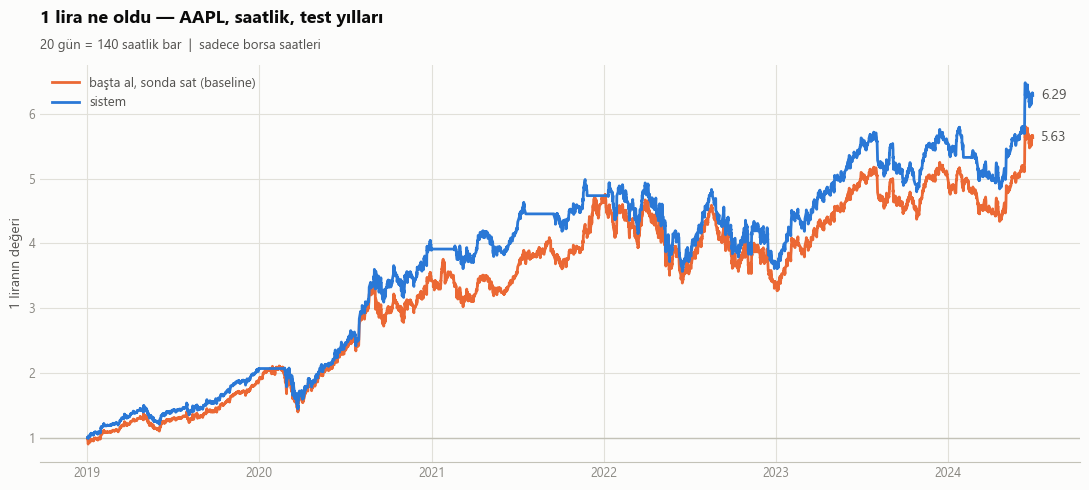

In [16]:
if FREKANS == '1Day':
    n_s = PENCERE_GUN * 7
    veri_s = veri_yukle(SEMBOL, '1Hour')
    tablo_s, ys_s, _ = egitim_test_detay(veri_s, n=n_s, test_yillari=TEST_YILLARI,
                                          maliyet=MALIYET, sabit=SABIT)
    sistem_s = zincirle(ys_s, n_s)
    baseline_s = al_tut(veri_s, f'{TEST_YILLARI.start}-01-01', maliyet=MALIYET)
    islem_s = sum(len(s.islemler) for s in ys_s.values())
    display(pd.DataFrame({
        'günlük': [sistem.iloc[-1], baseline.iloc[-1], len(tum_islemler),
                   int((tablo['testte'] > tablo['basta_al_sonda_sat']).sum())],
        'saatlik': [sistem_s.iloc[-1], baseline_s.iloc[-1], islem_s,
                    int((tablo_s['testte'] > tablo_s['basta_al_sonda_sat']).sum())],
    }, index=['sistem 1 lira →', 'baseline (kesintisiz) 1 lira →', 'işlem',
              "baseline'ı geçtiği yıl"]))
    plots.compare_equity_chart(sistem_s, baseline_s,
                               baslik=f'1 lira ne oldu — {SEMBOL}, saatlik, test yılları',
                               alt_baslik='20 gün = 140 saatlik bar  |  sadece borsa saatleri');

## 8b. Dakikalık veriyle karşılaştırma

Aynı sistem, aynı 20 günlük çizgiler (20 × 390 = 7800 dakikalık bar), aynı
eğitim/test. Tek fark: kararlar her dakika verilir. Fiyat dibe ya da takip
eden stop'a değdiği dakikada işlem yapılır, saatin sonunu beklemez.

Dakikalık veri sadece araştırma dönemi için indirildi (2016-01 → 2024-06);
saklanan dönemin dakikalık verisi hiç indirilmedi. Bu adım sadece ayarlarda
`FREKANS = '1Day'` iken çalışır. Çalışması birkaç dakika sürer.

,günlük,saatlik,dakikalık
sistem 1 lira →,5.804,6.285,6.324
maliyet olmasa 1 lira →,5.933,6.529,6.465
baseline (kesintisiz) 1 lira →,5.662,5.634,5.567
işlem,22,38,22
zararına satılan,4,19,3
baseline'ı geçtiği yıl,4,5,5
en büyük erime (sistem),-27.6%,-30.5%,-30.8%
en büyük erime (baseline),-31.4%,-33.8%,-35.0%


,test_yili,secilen_alim,secilen_stop,secilen_takip,egitimde,testte,varsayilan_esiklerle,basta_al_sonda_sat
0,2019,0.100,1.000,1.000,0.670,1.066,0.530,0.884
1,2020,0.100,1.000,1.000,2.148,0.917,0.481,0.822
2,2021,0.100,2.000,1.000,5.385,0.196,0.045,0.347
3,2022,0.100,2.000,1.000,6.500,-0.210,-0.106,-0.265
4,2023,0.100,2.000,1.000,4.922,0.506,0.260,0.489
5,2024,0.100,2.000,1.000,7.822,0.123,0.191,0.096


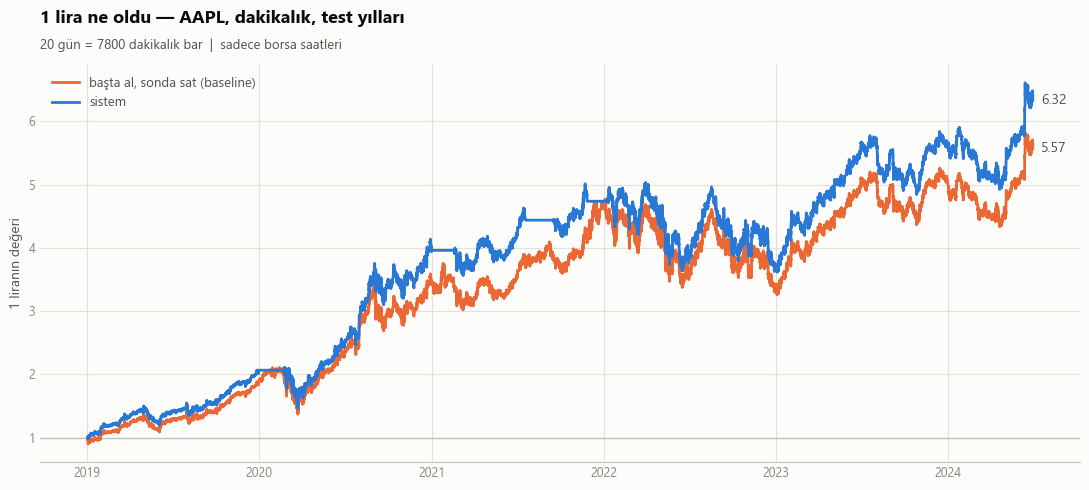

In [17]:
if FREKANS == '1Day':
    from lab.backtest import en_buyuk_dusus
    n_d = PENCERE_GUN * 390
    veri_d = veri_yukle(SEMBOL, '1Min')
    tablo_d, ys_d, _ = egitim_test_detay(veri_d, n=n_d, test_yillari=TEST_YILLARI,
                                          maliyet=MALIYET, sabit=SABIT)
    sistem_d = zincirle(ys_d, n_d)
    baseline_d = al_tut(veri_d, f'{TEST_YILLARI.start}-01-01', maliyet=MALIYET)

    def ozetle(tbl, ys, sis, base):
        isl = pd.concat([s.islemler for s in ys.values()])
        return [sis.iloc[-1], float(np.prod(1 + isl['getiri'])), base.iloc[-1],
                len(isl), int((isl['sebep'] == 'stop').sum()),
                int((tbl['testte'] > tbl['basta_al_sonda_sat']).sum()),
                f'{en_buyuk_dusus(sis):.1%}', f'{en_buyuk_dusus(base):.1%}']

    display(pd.DataFrame({
        'günlük': ozetle(tablo, yil_sonuclari, sistem, baseline),
        'saatlik': ozetle(tablo_s, ys_s, sistem_s, baseline_s),
        'dakikalık': ozetle(tablo_d, ys_d, sistem_d, baseline_d),
    }, index=['sistem 1 lira →', 'maliyet olmasa 1 lira →', 'baseline (kesintisiz) 1 lira →',
              'işlem', 'zararına satılan', "baseline'ı geçtiği yıl",
              'en büyük erime (sistem)', 'en büyük erime (baseline)']))
    display(tablo_d)
    plots.compare_equity_chart(sistem_d, baseline_d,
                               baslik=f'1 lira ne oldu — {SEMBOL}, dakikalık, test yılları',
                               alt_baslik='20 gün = 7800 dakikalık bar  |  sadece borsa saatleri');

## 8c. Baseline ile fark ne kadar hızlı açıldı

Soru: günlükte sistemin baseline'ı geçmesi uzun sürüyor, saatlikte daha hızlı
oluyor. Dakikalıkta daha da mı hızlı?

Grafik her gün için **sistem ÷ baseline − 1** değerini gösterir: 0'ın üstü
sistemin baseline'dan önde olduğu günler. Eğri ne kadar erken yükselirse fark
o kadar hızlı açılmış demektir. Üç veri aynı eksende kıyaslansın diye her
günün son barı alınır. Tablo her yılın sonundaki farkı gösterir.

,günlük,saatlik,dakikalık
yıl sonu,,,
2019,-4.1%,+9.7%,+9.7%
2020,+1.4%,+13.9%,+15.3%
2021,-9.4%,+2.3%,+2.3%
2022,-2.6%,+9.2%,+9.8%
2023,+0.5%,+9.7%,+11.0%
2024,+2.5%,+11.6%,+13.6%


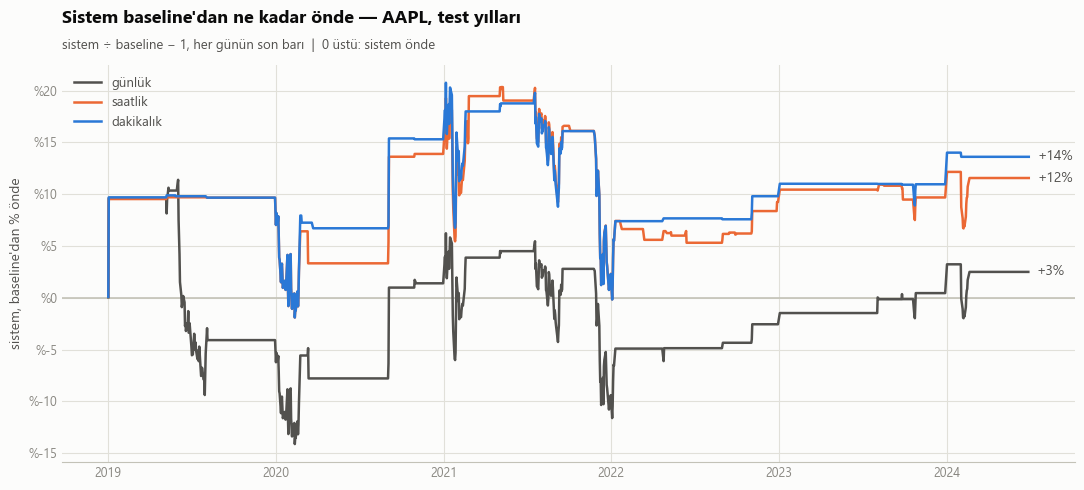

In [18]:
if FREKANS == '1Day':
    seriler = {'günlük': (sistem, baseline),
               'saatlik': (sistem_s, baseline_s),
               'dakikalık': (sistem_d, baseline_d)}

    def yil_sonu_fark(sis, base):
        f = sis / base.reindex(sis.index) - 1
        return f.groupby(f.index.year).last()

    fark = pd.DataFrame({ad: yil_sonu_fark(*sb) for ad, sb in seriler.items()})
    display(fark.rename_axis('yıl sonu').apply(lambda s: s.map('{:+.1%}'.format)))
    plots.gap_chart(seriler, baslik=f"Sistem baseline'dan ne kadar önde — {SEMBOL}, test yılları",
                    alt_baslik='sistem ÷ baseline − 1, her günün son barı  |  0 üstü: sistem önde');

## 9. Sınırlar ve sonraki adımlar

**Kabulün sınırları** (ayrıntı: `hypotheses/KABUL-1_AAPL_takip_eden_stop.md`):

* Sadece **AAPL için**. Tipin kuralı sayılması için aynı tipten en az 3 hissede test edilmeli.
* Fark küçük ve ~71 denemeden sonra geldi. Önceden yazılmış bir kabul kriteri yoktu.
* Sistem zamanın ~%85-90'ında piyasada; düşüşe karşı koruma sınırlı.
* Takip mesafesi, denenen en geniş değerde (1.0). Daha genişi al-tut'a dönüşüyor.
* Yıl sonu satışları test yönteminden geliyor; gerçek sistemde olmaz.
* Saklanan veride ve sanal hesapta henüz denenmedi.

**Sonraki adımlar:**

1. Aynı tipten 2+ hissede (MSFT, NVDA) bu defter: ayarlarda `SEMBOL` değişir.
2. Yıl sonu satışı olmadan, pozisyonu yıllar arasında taşıyan eğitim/test.
3. Sanal hesap (ENV-B): `docs/ALIM_SATIM_MOTORU.md`.